# Chapter C. Multiple Hypothesis Testing

## Learning Objectives

After completing this chapter, you should be able to:
1. Distinguish per-test Type I error, FWER（家族错误率）, FDR（错误发现率）, and FDP.
2. Compute BH-adjusted q-values across the whole candidate-by-lag family.
3. Explain why correlated or invalid p-values can compromise FDR control.
4. Compare Bonferroni, BH, and BY adjustments on reproducible data.
5. Distinguish complete-null FDR from mixed-null mean FDP.

**Connection to STARM:** The examples mirror the binary outcome, fixed antecedent indicators, lagged transactions, and overlapping spatial supports in the STARM manuscript. They are teaching examples, not reproductions of manuscript results.

> **Teaching philosophy:** start with the general statistical problem, build mathematical intuition, and use STARM as one illustrative case study. The new sections precede the original computational labs.

## Why Study This? — Motivation, Scope, and Real-World Problems

When we test many hypotheses, individual error rates accumulate: this is the **multiple comparisons problem (多重比较问题)**. This appears in genomics, neuroimaging, high-throughput screening, sensor networks, and algorithmic pattern mining. If 1,000 independent true nulls are tested at 0.05, the expected number of false rejections is 50.

**Questions it answers:** What does “5% error” mean across a large research search? How many false findings can we tolerate? When do dependence and data-driven selection invalidate a correction?

---

## Conceptual Roadmap

**Scientific problem → statistical representation → assumptions → mathematics → computational experiment → diagnostics → interpretation.**

The chapters are standalone: STARM is a later application, not the reason these mathematical ideas exist.

## Foundations and Mathematical Derivations

### Error quantities and why they differ
Let $V$ denote false discoveries, $S$ true discoveries, $R=V+S$, and $M$ the number of tests. Define

$$\mathrm{FWER}=P(V\ge1),\qquad\mathrm{FDP}=\frac{V}{\max(R,1)},\qquad\mathrm{FDR}=E[\mathrm{FDP}].$$

**FWER** (族错误率) protects against *any* false rejection; **FDR** (错误发现率) controls the *expected proportion* of false rejections. Under the complete null, $R=V$, so $\mathrm{FDR}=P(V>0)=\mathrm{FWER}$. With true signals present, they differ.

### Bonferroni, BH, and BY from first principles
Bonferroni rejects test $i$ if $p_i\le\alpha/M$: by the union bound $P(V>0)\le\sum_{i\in H_0}P(p_i\le\alpha/M)\le\alpha$, provided true-null p-values are valid. No independence is required.

**Benjamini–Hochberg (BH):** order $p_{(1)}\le\cdots\le p_{(M)}$; let $k^*=\max\{k:p_{(k)}\le k\alpha/M\}$. Reject $p_i\le p_{(k^*)}$; no rejections if no qualifying $k$. Standard BH control holds under independence or certain positive dependence (PRDS), assuming valid true-null p-values.

**Benjamini–Yekutieli (BY):** replace $\alpha$ with $\alpha/H_M$, $H_M=\sum_{j=1}^{M}1/j$. It controls FDR under arbitrary dependence *of valid p-values*, at an often substantial power cost. Neither BH nor BY fixes invalid marginal p-values.

### Correlation, selection, and hypothesis families
Nested tests (e.g. $A$ and $A\cap B$), repeated lags, shared data, and threshold scans create correlated p-values. Positive correlation by itself does not establish PRDS. If a rule is selected *using the outcomes* and then tested as if it were prespecified, selection bias may invalidate inference. A valid design may use outcome-independent filters, sample splitting, or explicit selective-inference methods.

### Critical thinking checkpoint
Before running code, write down which observations are assumed independent or exchangeable and explain why. Revisit this statement after inspecting the visualizations.

### Why multiple-testing error rates were invented
Imagine testing one prespecified hypothesis at level $\alpha=0.05$: under a valid null, the long-run false-rejection probability is at most 5%. Now test $M$ null hypotheses and announce every nominally significant result. If all nulls are true and tests are independent, the chance of at least one false announcement is

$$P(V\ge1)=1-(1-\alpha)^M.$$

At $M=100$, this is about 0.994, not 0.05. Spatial scans, many biomarkers, subgroup comparisons, candidate rules, and repeated time lags all create this *multiplicity problem*: the analyst wants a useful set of findings, but the chance and fraction of false findings can grow as the search expands.

For one realized analysis, let $V$ be the number of false rejections, $S$ the number of true rejections, and $R=V+S$ the total number rejected. The **false discovery proportion** is the realized false share,

$$\mathrm{FDP}=\frac{V}{\max(R,1)}.$$

It is defined as zero when nothing is rejected. We cannot usually observe $V$ in a real study because the truth of each hypothesis is unknown. The **false discovery rate** is therefore the repeated-study expectation

$$\mathrm{FDR}=E[\mathrm{FDP}],$$

while the **family-wise error rate** is the probability of at least one false rejection,

$$\mathrm{FWER}=P(V\ge1).$$

FWER answers “how often will this analysis make even one false claim?” FDP answers “what share of this particular rejection list is false?” FDR answers “across repetitions, what is the expected false share?” Under the complete null, $V=R$, so FDP is 1 whenever there is any rejection and 0 otherwise; consequently $\mathrm{FDR}=\mathrm{FWER}$. With real signals present, FDR can be much smaller than FWER. They target different scientific decisions, not competing definitions of the same quantity.

### The design path: Bonferroni, then BH, then BY
**Bonferroni: protect against any false alarm.** If the cost of even one false claim is unacceptable, allocate a total error budget $\alpha$ across the family: reject test $i$ only when $p_i\le\alpha/M$. For valid null p-values,

$$P(V\ge1)\le\sum_{i\in H_0}P(p_i\le\alpha/M)\le M_0\frac{\alpha}{M}\le\alpha.$$

This is the union bound; it needs no independence. The price is that every test faces the same small threshold, even when the analysis contains many true signals and the goal is to rank promising leads. Bonferroni is attractive for a small, prespecified family or high-stakes confirmatory claims. It is conservative because the bound does not exploit the actual dependence or structure.

**BH: control the expected false share of a discovery list.** Benjamini and Hochberg (1995) asked whether exploratory multiple testing could control the expected proportion of false rejections rather than the probability of *any* error. This changes the target to FDR and can retain more power when some hypotheses are truly non-null. Sort the p-values $p_{(1)}\le\cdots\le p_{(M)}$, find

$$k^*=\max\left\{k:p_{(k)}\le\frac{kq}{M}\right\},$$

and reject the hypotheses with ranks $1,\ldots,k^*$. If no rank passes, reject none. BH controls FDR at most $(M_0/M)q\le q$ for independent valid p-values, and also under the standard PRDS positive-dependence condition. Correlation alone does not prove PRDS.

**BY: retain an FDR guarantee under arbitrary dependence.** Spatial overlap and shared outcomes can make the p-values dependent in ways that do not satisfy BH's guarantee. Benjamini and Yekutieli (2001) replaced $q$ by $q/H_M$, where $H_M=\sum_{j=1}^M1/j$, giving thresholds $kq/(M H_M)$. BY controls FDR under arbitrary dependence when the true-null p-values are valid. The harmonic factor can make it much more conservative. BY addresses dependence among tests; it does **not** repair a misspecified null model, invalid permutation p-values, outcome-driven selection, or unrecorded analyses.

### How to use the procedures in practice
1. **Define the family before seeing outcomes.** State which locations, outcomes, groups, radii, time lags, and thresholds count as one search. Do not quietly split a large search into favorable small families.
2. **Validate each marginal p-value first.** The null model and sampling/randomization design must match the data. Multiplicity adjustment cannot make invalid p-values valid.
3. **Choose the error target from the decision.** Use FWER control when any false positive is costly (e.g. confirmatory claims or triggering costly intervention). Use FDR control when producing a ranked exploratory list and a limited false share is acceptable.
4. **Choose dependence handling.** Bonferroni and BY work under arbitrary dependence of valid p-values; standard BH needs independence or PRDS. For strong structured dependence, consider a design-valid block/randomization max-statistic or a specialist procedure.
5. **Report the family size, method, adjusted p-values/rejection set, effect estimates, and intervals.** Significance alone does not show importance or causal effect.

For the five p-values $(0.001,0.012,0.020,0.070,0.40)$ at $q=0.05$, Bonferroni rejects only $0.001$; BH finds $k^*=3$ and rejects the first three; BY is more stringent and rejects only $0.001$. This is a worked arithmetic illustration, not evidence that one method is universally best.

**Historical sources.** Benjamini & Hochberg (1995), [*Controlling the False Discovery Rate: A Practical and Powerful Approach to Multiple Testing*](https://doi.org/10.1111/j.2517-6161.1995.tb02031.x), explicitly motivate FDR as an alternative to FWER with potential power gains. Benjamini & Yekutieli (2001), [*The Control of the False Discovery Rate in Multiple Testing under Dependency*](https://doi.org/10.1214/aos/1013699998), treat dependent tests. For the Bonferroni inequality and simultaneous-coverage interpretation, see the [NIST/SEMATECH e-Handbook](https://www.itl.nist.gov/div898/handbook/prc/section4/prc473.htm).

### Error, power, and confidence intervals in a search over many hypotheses
For one valid test, **Type I error** is rejecting a true null, with long-run probability controlled at $\alpha$; **Type II error** ($\beta$) is missing a specified true effect; and **power** is $1-\beta$. A confidence interval describes a repeated-sampling coverage procedure, not a probability distribution over a fixed effect. Power depends on effect size, sample size, noise, and the decision rule, so $\beta$ is not one universal number.

With $M$ hypotheses, a per-test $\alpha=0.05$ does not mean the whole search has a 5% false-alarm probability. FWER is $P(V\ge1)$, while FDR is the expected false-discovery proportion $E[V/\max(R,1)]$. Bonferroni controls FWER under valid p-values; BH controls FDR under independence or appropriate positive dependence; BY is more conservative but allows arbitrary dependence among valid p-values. Correction can reduce power, especially for weak or rare signals.

### A hypergeometric null for one candidate
If a pre-specified candidate rule marks $n$ of $N$ site-weeks and exactly $m$ site-weeks have an event, the overlap $K$ has a hypergeometric reference under uniform fixed-margin allocation:

$$P(K=k)=\frac{\binom nk\binom{N-n}{m-k}}{\binom Nm},\quad E[K]=n\frac mN,\quad \mathrm{Var}(K)=n\frac mN\left(1-\frac mN\right)\frac{N-n}{N-1}.$$

$K$ is random; $E[K]$ and $\mathrm{Var}(K)$ are scalar summaries fixed by $N,n,m$, not distributions of their own. The PMF is discrete and can be skewed for rare outcomes. For example, among 500 site-weeks with 60 event weeks, a candidate alert covering 100 site-weeks has expected overlap 12; sampling without replacement reduces its variance by the finite-population correction. Across many candidates and lags, these overlaps share outcomes and are dependent: the per-candidate hypergeometric null alone does not justify BH's dependence assumptions or repair invalid p-values.

### Realistic screening example: neighborhood health alerts
Imagine a public-health team predefines 200 neighborhoods and tests whether each has an unusually high heat-related emergency rate during the same month. These are **constructed data for teaching**, not findings about an actual city. The team should report effect estimates and confidence intervals, control a prespecified family of tests, and use a null model that accounts for shared weather and neighboring neighborhoods. The simulation below contrasts unadjusted, Bonferroni, BH, and BY decisions under an idealized independent-test model; it shows expected behavior, not a guarantee for correlated spatial tests.

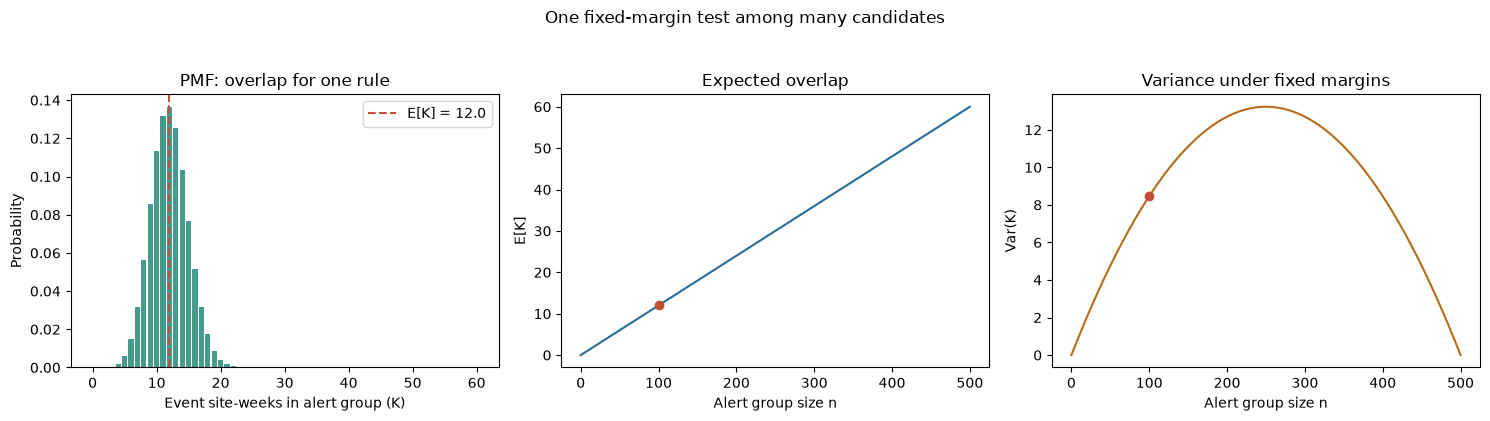

N=500, m=60, n=100
E[K]=12.000; Var(K)=8.465; SD(K)=2.909
PMF sums to 1.000000


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import hypergeom

population_size = 500
observed_event_site_weeks = 60
alert_site_weeks = 100
possible_overlaps = np.arange(
    max(0, alert_site_weeks - (population_size - observed_event_site_weeks)),
    min(alert_site_weeks, observed_event_site_weeks) + 1,
)
overlap_probabilities = hypergeom.pmf(
    possible_overlaps,
    population_size,
    observed_event_site_weeks,
    alert_site_weeks,
)
expected_overlap = hypergeom.mean(
    population_size, observed_event_site_weeks, alert_site_weeks
)
variance_overlap = hypergeom.var(
    population_size, observed_event_site_weeks, alert_site_weeks
)

candidate_sizes = np.arange(population_size + 1)
event_fraction = observed_event_site_weeks / population_size
expected_by_size = candidate_sizes * event_fraction
variance_by_size = (
    candidate_sizes * event_fraction * (1 - event_fraction)
    * (population_size - candidate_sizes) / (population_size - 1)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(possible_overlaps, overlap_probabilities, color="#278a78", alpha=0.85)
axes[0].axvline(expected_overlap, color="#c34e36", linestyle="--", label=f"E[K] = {expected_overlap:.1f}")
axes[0].set(title="PMF: overlap for one rule", xlabel="Event site-weeks in alert group (K)", ylabel="Probability")
axes[0].legend()
axes[1].plot(candidate_sizes, expected_by_size, color="#276c9b")
axes[1].scatter([alert_site_weeks], [expected_overlap], color="#c34e36", zorder=3)
axes[1].set(title="Expected overlap", xlabel="Alert group size n", ylabel="E[K]")
axes[2].plot(candidate_sizes, variance_by_size, color="#b66c19")
axes[2].scatter([alert_site_weeks], [variance_overlap], color="#c34e36", zorder=3)
axes[2].set(title="Variance under fixed margins", xlabel="Alert group size n", ylabel="Var(K)")
fig.suptitle("One fixed-margin test among many candidates", y=1.04)
fig.tight_layout()
plt.show()
print(f"N={population_size}, m={observed_event_site_weeks}, n={alert_site_weeks}")
print(f"E[K]={expected_overlap:.3f}; Var(K)={variance_overlap:.3f}; SD(K)={np.sqrt(variance_overlap):.3f}")
print(f"PMF sums to {overlap_probabilities.sum():.6f}")

### Simulation: what multiplicity correction does to error and power
The following experiment generates independent two-group tests. First, all 200 null hypotheses are true; we estimate the probability of at least one false rejection (FWER). Then 10 of 200 hypotheses have a real 6-percentage-point increase; we compare the average false-discovery proportion and the fraction of those 10 signals detected. This is an idealized independent-test benchmark, not a model of correlated neighborhoods. Monte Carlo estimates vary with the seed and number of repetitions.

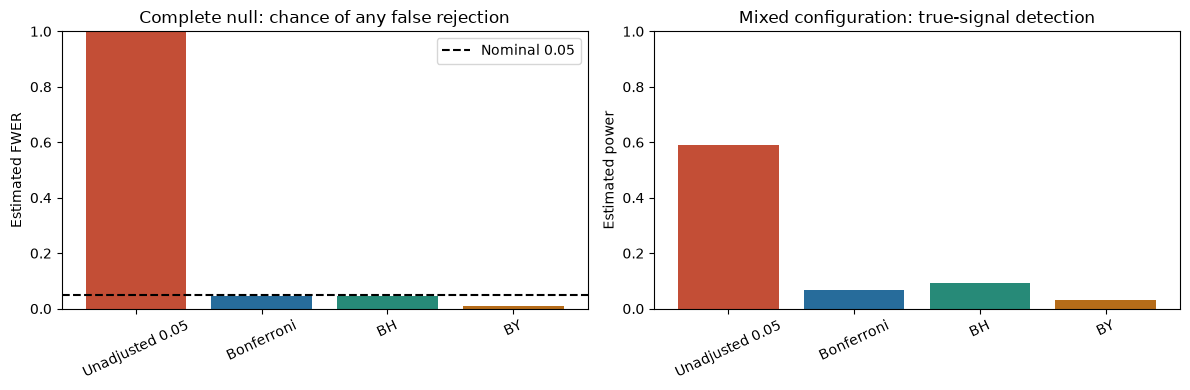

Complete-null FWER: {'Unadjusted 0.05': np.float64(1.0), 'Bonferroni': np.float64(0.045), 'BH': np.float64(0.047), 'BY': np.float64(0.01)}
Mixed-null results (means across repetitions):
         method  mean FDP  FWER  signal power
Unadjusted 0.05     0.611 1.000         0.590
     Bonferroni     0.025 0.037         0.066
             BH     0.040 0.086         0.092
             BY     0.005 0.008         0.030


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

simulation_rng = np.random.default_rng(20261008)
number_of_tests = 200
sample_size_per_arm = 300
replications = 2500
alpha = 0.05
null_rate = 0.10
signal_rate = 0.16
number_of_signals = 10


def two_proportion_pvalues(control_counts, treatment_counts, n):
    pooled_rate = (control_counts + treatment_counts) / (2 * n)
    standard_error = np.sqrt(pooled_rate * (1 - pooled_rate) * 2 / n)
    z_values = np.divide(
        treatment_counts / n - control_counts / n,
        standard_error,
        out=np.zeros_like(pooled_rate, dtype=float),
        where=standard_error > 0,
    )
    return 2 * norm.sf(np.abs(z_values))


def step_up_rejections(p_values, alpha, dependence_factor=1.0):
    order = np.argsort(p_values, axis=1)
    sorted_p = np.take_along_axis(p_values, order, axis=1)
    thresholds = (
        alpha * np.arange(1, p_values.shape[1] + 1)
        / (p_values.shape[1] * dependence_factor)
    )
    passes = sorted_p <= thresholds
    largest_passing_rank = np.max(
        np.where(passes, np.arange(1, p_values.shape[1] + 1), 0), axis=1
    )
    cutoff_index = np.maximum(largest_passing_rank - 1, 0)
    cutoff = np.take_along_axis(sorted_p, cutoff_index[:, None], axis=1)
    return (p_values <= cutoff) & (largest_passing_rank[:, None] > 0)


def compare_procedures(p_values, true_signal_count):
    procedures = {
        "Unadjusted 0.05": p_values <= alpha,
        "Bonferroni": p_values <= alpha / number_of_tests,
        "BH": step_up_rejections(p_values, alpha),
        "BY": step_up_rejections(
            p_values, alpha, np.sum(1 / np.arange(1, number_of_tests + 1))
        ),
    }
    rows = []
    for name, rejected in procedures.items():
        false_rejections = rejected[:, true_signal_count:].sum(axis=1)
        total_rejections = rejected.sum(axis=1)
        false_discovery_proportion = false_rejections / np.maximum(total_rejections, 1)
        signal_power = rejected[:, :true_signal_count].mean()
        rows.append({
            "method": name,
            "mean FDP": false_discovery_proportion.mean(),
            "FWER": np.mean(false_rejections > 0),
            "signal power": signal_power,
        })
    return pd.DataFrame(rows)


# Complete null: every rejection is false, so FWER is the chance of any rejection.
null_control = simulation_rng.binomial(
    sample_size_per_arm, null_rate, size=(replications, number_of_tests)
)
null_treatment = simulation_rng.binomial(
    sample_size_per_arm, null_rate, size=(replications, number_of_tests)
)
complete_null_p_values = two_proportion_pvalues(
    null_control, null_treatment, sample_size_per_arm
)
complete_null_fwer = {
    "Unadjusted 0.05": np.mean(np.any(complete_null_p_values <= alpha, axis=1)),
    "Bonferroni": np.mean(np.any(complete_null_p_values <= alpha / number_of_tests, axis=1)),
    "BH": np.mean(np.any(step_up_rejections(complete_null_p_values, alpha), axis=1)),
    "BY": np.mean(np.any(step_up_rejections(
        complete_null_p_values, alpha,
        np.sum(1 / np.arange(1, number_of_tests + 1)),
    ), axis=1)),
}

# Mixed configuration: the first 10 hypotheses have a 6-point increase.
control_probabilities = np.full(number_of_tests, null_rate)
treatment_probabilities = control_probabilities.copy()
treatment_probabilities[:number_of_signals] = signal_rate
mixed_control = simulation_rng.binomial(
    sample_size_per_arm, control_probabilities, size=(replications, number_of_tests)
)
mixed_treatment = simulation_rng.binomial(
    sample_size_per_arm, treatment_probabilities, size=(replications, number_of_tests)
)
mixed_p_values = two_proportion_pvalues(
    mixed_control, mixed_treatment, sample_size_per_arm
)
mixed_results = compare_procedures(mixed_p_values, number_of_signals)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
method_names = list(complete_null_fwer)
axes[0].bar(method_names, [complete_null_fwer[name] for name in method_names], color=["#c34e36", "#276c9b", "#278a78", "#b66c19"])
axes[0].axhline(alpha, color="black", linestyle="--", label="Nominal 0.05")
axes[0].set(title="Complete null: chance of any false rejection", ylabel="Estimated FWER", ylim=(0, 1))
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend()
axes[1].bar(mixed_results["method"], mixed_results["signal power"], color=["#c34e36", "#276c9b", "#278a78", "#b66c19"])
axes[1].set(title="Mixed configuration: true-signal detection", ylabel="Estimated power", ylim=(0, 1))
axes[1].tick_params(axis="x", rotation=25)
fig.tight_layout()
plt.show()
print("Complete-null FWER:", {key: round(value, 3) for key, value in complete_null_fwer.items()})
print("Mixed-null results (means across repetitions):")
print(mixed_results.round(3).to_string(index=False))

**Interpretation.** Under the complete null, each unadjusted test is calibrated at 0.05 but the chance of at least one false alarm across 200 tests is about 1. The corrections reduce that family-level risk. In the mixed case, estimated $\beta=1-\text{power}$ is about 0.934 for Bonferroni, 0.908 for BH, and 0.970 for BY; this design has many weak signals relative to the 200-test family, so stringent correction misses most of them. The answer is not to skip correction: improve measurement/sample size, prespecify a smaller scientific family, or validate discoveries in independent data. These independence-based results do not establish control for spatially correlated neighborhoods.

## Additional Derivation Visualization — General-Purpose Example

The following self-contained experiment illustrates a general statistical principle, not STARM-specific results. Check how the plot corresponds to the formulas above.

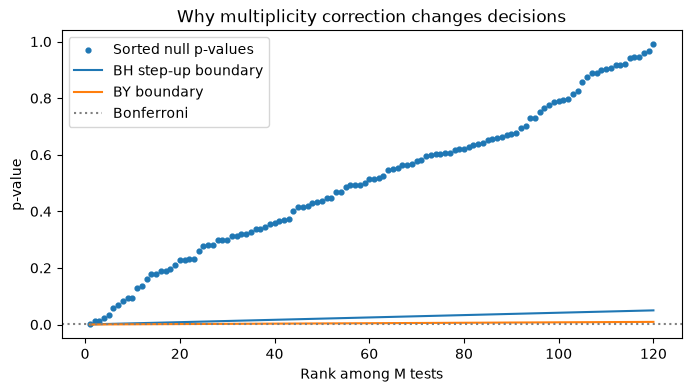

Expected false rejections under uncorrected alpha: 6.0


In [3]:
import numpy as np
import matplotlib.pyplot as plt
rng=np.random.default_rng(2026)
M=120; alpha=.05
p=np.sort(rng.uniform(size=M)); idx=np.arange(1,M+1)
H=np.sum(1/idx)
fig,ax=plt.subplots(figsize=(8,4))
ax.scatter(idx,p,s=12,label='Sorted null p-values')
ax.plot(idx,alpha*idx/M,label='BH step-up boundary')
ax.plot(idx,alpha*idx/(M*H),label='BY boundary')
ax.axhline(alpha/M,color='gray',ls=':',label='Bonferroni')
ax.set(xlabel='Rank among M tests',ylabel='p-value',title='Why multiplicity correction changes decisions')
ax.legend();plt.show()
print('Expected false rejections under uncorrected alpha:',M*alpha)

```mermaid
flowchart LR
    A[Enumerate candidates × lags] --> B[Compute valid p-values]
    B --> C[Sort all p-values]
    C --> D[BH step-up threshold]
    D --> E[Identify R and V]
    E --> F[Estimate mean FDP over replicates]
```

This chapter follows the same structure as the supplied MCLP tutorial: conceptual workflow, formal definition, assumptions, a hand-worked example, executable Python experiments, sensitivity checks, common pitfalls, and a quiz.

---

## Formal Definition and Core Equations

### Notation

| Symbol | Meaning |
|---|---|
| $M$ | total number of tested candidate-by-lag hypotheses |
| $R$ | number of rejected hypotheses |
| $V$ | number of false rejections（错误发现数量） |
| $\mathrm{FDP}$ | realized false discovery proportion |
| $\mathrm{FDR}$ | expectation of FDP |
| $\alpha$ | nominal target error level |

$$\mathrm{FDP}=\frac{V}{\max(R,1)},\qquad\mathrm{FDR}=E[\mathrm{FDP}].$$

$$p_{(k)}\le\frac{k\alpha}{M}\quad\text{(BH step-up criterion)},\qquad q_{(i)}=\min_{j\ge i}\frac{M p_{(j)}}j\wedge1.$$

Under the **complete null**, $V=R$, so $\mathrm{FDR}=P(R>0)$; this equality generally fails under a mixed null.

---

## Core Mechanisms and Concepts

### Families matter

STARM tests candidate × lag combinations, not just each antecedent separately. Fix the allowed antecedents and lag range in advance, and adjust across the complete tested family.

### FWER versus FDR

FWER controls the probability of any false rejection; FDR controls the expected fraction of rejected rules that are false, including repetitions with no rejections.

### Dependence caveat

BH provides guarantees for valid null p-values under specified dependence assumptions (such as independence and PRDS). Shared environmental conditions and nested rules do **not** automatically establish PRDS. BY is conservative under arbitrary dependence **if the input null p-values are valid**. Neither adjustment rescues invalid spatial permutations.

## Assumptions, Strengths, Limitations, and Trade-offs

Assume known hypothesis family, proper null p-values, and interpret the chosen correction under its theoretical dependence assumptions. Strength: explicit adjustment for extensive search. Limitation: a small empirical mixed-null mean FDP does not establish general FDR control.

**Trade-off:** aggressive screening and stronger correction can reduce false detections but may lower power for rare compound rules.

## Worked Toy Example

Five candidate-by-lag tests produce p-values $(0.001,0.012,0.020,0.070,0.40)$. At $\alpha=0.05$, compare each ordered p-value with $(1,2,3,4,5)\times0.05/5$. The largest passing rank determines all BH rejections up to that rank. Do **not** test each lag in its own family unless that is the prespecified scientific family.

## Python Lab: Set Up the Dataset

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import hypergeom, binom

SEED = 41020001
rng = np.random.default_rng(SEED)
print("Reproducible random seed:", SEED)

Reproducible random seed: 41020001


## Manually compute BH decisions

Implement BH and BY without an additional statistics package.

In [5]:
def bh_qvals(p):
 p=np.asarray(p,float);m=len(p);order=np.argsort(p);ranks=np.arange(1,m+1)
 q_sorted=np.minimum.accumulate((m*p[order]/ranks)[::-1])[::-1]
 q=np.empty(m);q[order]=np.minimum(q_sorted,1);return q
p=np.array([.001,.012,.020,.070,.40]);q=bh_qvals(p)
print(pd.DataFrame({'p':p,'BH q':q,'BH reject':q<=.05,'Bonferroni reject':p<=.05/len(p)}))

       p      BH q  BH reject  Bonferroni reject
0  0.001  0.005000       True               True
1  0.012  0.030000       True              False
2  0.020  0.033333       True              False
3  0.070  0.087500      False              False
4  0.400  0.400000      False              False


**Interpretation.** Sort over the complete family. BH thresholding is not the same as testing each raw p-value at 0.05.

## Compare BH and BY

BY adds the harmonic factor H_M and is more conservative.

In [6]:
H=sum(1/j for j in range(1,len(p)+1))
q_by=np.minimum(1,q*H)
print(pd.DataFrame({'p':p,'BH_q':q,'BY_q':q_by}).round(4))

       p    BH_q    BY_q
0  0.001  0.0050  0.0114
1  0.012  0.0300  0.0685
2  0.020  0.0333  0.0761
3  0.070  0.0875  0.1998
4  0.400  0.4000  0.9133


**Interpretation.** The BY correction addresses arbitrary dependence of VALID p-values; it cannot fix the anti-conservatism of a misspecified spatial reference.

## Simulate complete-null family rejection

Independent uniform p-values let us see how the correction works when assumptions hold.

In [7]:
R=2500;M=45
ps=rng.uniform(size=(R,M))
any_bh=np.array([(bh_qvals(v)<=.05).any() for v in ps])
any_raw=np.array([(v<=.05).any() for v in ps])
print({'raw_any_rejection':any_raw.mean(),'BH_complete_null_FDR':any_bh.mean()})

{'raw_any_rejection': np.float64(0.9004), 'BH_complete_null_FDR': np.float64(0.0456)}


**Interpretation.** Under complete null, FDR is the probability of at least one rejection. This simple experiment has independent p-values, unlike spatial overlap.

## Simulate a mixed-null family

Calculate FDP on each replicate, including replicates with zero discoveries.

{'mean_FDP_FDR_estimate': np.float64(0.034792857142857146), 'true_positive_fraction': np.float64(0.17793333333333336)}


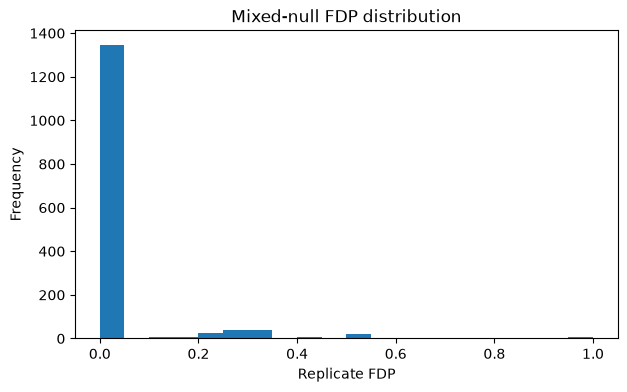

In [8]:
R=1500;M0=35;M1=10;fdps=[];powers=[]
for _ in range(R):
 p0=rng.uniform(size=M0);p1=rng.beta(.3,1,size=M1)
 rej=bh_qvals(np.r_[p0,p1])<=.05
 fdps.append(rej[:M0].sum()/max(1,rej.sum()))
 powers.append(rej[M0:].mean())
print({'mean_FDP_FDR_estimate':np.mean(fdps),'true_positive_fraction':np.mean(powers)})
fig,ax=plt.subplots(figsize=(7,4));ax.hist(fdps,bins=20);ax.set(xlabel='Replicate FDP',ylabel='Frequency',title='Mixed-null FDP distribution');plt.show()

**Interpretation.** A low mean FDP can coexist with poor power; the number of true rules and effect strength affect performance.

---

## Common Pitfalls and Misunderstandings

- Reporting $V/R$ after pooling all simulations is not the same as averaging replicate FDPs.
- A complete-null rejection rate and mixed-null FDR answer different questions.
- Nested rules and nearby lags can yield correlated p-values; correlation alone proves neither BH validity nor failure.
- BH uses one prespecified family; post-hoc family changes invalidate naive interpretation.
- BY does not correct an invalid randomization test.

---

## Quiz — Self-Assessment (Answers Hidden)

Try each question before expanding **Answer**. The folded format follows the supplied `mclp.ipynb` template.

### Q1: In a complete-null experiment, FDR equals what?

A. Mean number of discoveries  
B. Probability of any rejection  
C. Statistical power  
D. Sample size

<details>
<summary>Answer</summary>

**B. Every discovery is false; FDP is 1 if any rejection occurs and 0 otherwise.**

</details>

---

### Q2: Can BY rescue p-values from a misspecified permutation model?

A. Always  
B. Only for M>100  
C. No  
D. Only for positively correlated tests

<details>
<summary>Answer</summary>

**C. BY assumes individually valid true-null p-values.**

</details>

---

### Q3: What is the central difference between FWER and FDR?

A. FDR controls probability of any error  
B. FWER controls any false rejection; FDR controls expected false fraction  
C. Both are identical always  
D. FDR needs normality

<details>
<summary>Answer</summary>

**B. They correspond to different scientific error budgets.**

</details>

---

### Q4: Why must a study define its test family before adjusting?

A. To reduce plotting time  
B. To select only significant results  
C. The number and selection of tested claims influence multiplicity and validity  
D. To force independence

<details>
<summary>Answer</summary>

**C. Changing the family after seeing outcomes can induce selection bias.**

</details>

---

### Reflection Question (no prescribed solution)

Name one assumption violation in your own research area and propose a simulation to measure how much it matters.


---

## Suggested Reading and STARM Crosswalk

- Agrawal & Srikant (1994): frequent-itemset search (background).
- Hope (1968); Phipson & Smyth (2010): randomization/Monte Carlo p-values (Chapter B).
- Benjamini & Hochberg (1995); Benjamini & Yekutieli (2001): multiple testing and dependence (Chapter C).
- Baddeley, Rubak & Turner (2015): spatial point patterns (Chapter D).
- Winkler et al. (2014): exchangeability blocks and permutation designs (Chapters B, D, E).
- STARM manuscript: Sections 3.3–3.6 for reference assumptions; Section 4 for simulations; Sections 5–6 for empirical limitations.

**Practice task:** Write a short reviewer note distinguishing a descriptive association from an inferential discovery, explicitly naming the null model and its assumptions.